In [1]:
# =============================================================================
# 1. IMPORTS AND SETUP
# =============================================================================
%load_ext autoreload
%autoreload 2
import os
import sys
import pathlib
import re
import gc
import yaml
import warnings
import time
from multiprocessing import Pool, cpu_count

# Suppress warnings
warnings.filterwarnings("ignore")

# --- Environment and JAX Configuration ---
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

import jax
from jax.lib import xla_bridge
import jax.numpy as jnp
import jax_cosmo.background as bkgrd

# platform = xla_bridge.get_backend().platform
try:
    platform = xla_bridge.get_backend().platform
except:
    from jax.extend import backend
    platform = backend.get_backend().platform
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
print(f"JAX backend: {platform}, Total devices: {jax.device_count()}, Local devices: {jax.local_device_count()}")

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()

# --- Library Imports ---
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import asdf
import healpy as hp
from tqdm import tqdm
import pickle as pk
import h5py as h5

# --- Matplotlib Configuration ---
plt.rcParams['text.usetex'] = True

# --- Add Project-Specific Paths ---
curr_path = pathlib.Path().absolute()
project_base = curr_path.parents[1] 
abs_path_data = project_base / "data"
abs_path_src = project_base / "src"
abs_path_results = project_base / "results"
abs_path_params = project_base / "param_files"

for path in [curr_path, abs_path_data, abs_path_src, abs_path_results, abs_path_params]:
    sys.path.append(str(path))

# --- Import Custom Modules ---
from godmax.get_radial_profiles import Profiles
from godmax.get_sim_maps import setup_sim_map, get_sim_map
import helpers.constants as constants




JAX backend: gpu, Total devices: 1, Local devices: 1


In [2]:
nside = 512
sim_file_path = '/work/hdd/bdne/spandey3/backlight/fiducial/100'
data_dir = f'{sim_file_path}/halos'
files = [f for f in os.listdir(data_dir)]
zlist = np.array(sorted(np.array([int(item) for item in files], dtype=int)))

z2chi_file = f'{sim_file_path}/z2chi_interp.txt'
z2chi = np.loadtxt(z2chi_file)

zlist_file = f'{sim_file_path}/zlist.txt'
zlist = np.loadtxt(zlist_file)
snap_num_all = zlist[:,0].astype(int)
zval_all = zlist[:,1]

indz_all = np.where((zval_all < 0.1) & (zval_all > 0.05))[0]


In [34]:
ymap_data = {}
gmap_data = {}
cl_yy = {}
cl_gy = {}
lmax = 3 * nside - 1



# nu_theta_ej_M_all = [0.0, -0.15, -0.1,  -0.05,  -0.025]
# for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
delta_fshmr_all = [0.0001, 0.2, 0.25, 0.3]
for jth, deltav in enumerate(delta_fshmr_all):
    map_ymap_all = np.zeros(12*nside**2)
    map_gal_all = np.zeros(12*nside**2)
    for indz in indz_all:              
        sdir = '/projects/bdne/spandey3/temp/'
        zcen = zval_all[indz]
        # save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_z{zcen:.3f}_nu_theta{nu_theta_ej_M}.pkl'
        save_map_fname = f'{sdir}/allmaps_sim_B12_nside{nside}_z{zcen:.3f}_delta{deltav}.pkl'        
        with open(save_map_fname, 'rb') as f:
            data = pk.load(f)
        map_ymap_all  += data['map_ymap']
        mock_gals_all = data['mock_gals_all']
        gal_ra_all, gal_dec_all = mock_gals_all[0][:,0], mock_gals_all[0][:,1]
        gal_pix_all = hp.ang2pix(nside, gal_ra_all, gal_dec_all, lonlat=True)
        map_gal_all += np.bincount(gal_pix_all, minlength=12*nside**2)
    # ymap_data[nu_theta_ej_M] = map_ymap_all
    # gmap_data[nu_theta_ej_M] = map_gal_all
    ymap_data[deltav] = map_ymap_all
    gmap_data[deltav] = map_gal_all







In [35]:
theta_fwhm_all_arcmin = [4.0, 8.0, 16.0, 32.0, 64.0]
ymap_data_smooth = {}
gmap_data_smooth = {}

for jth, nu_theta_ej_M in enumerate(delta_fshmr_all):
    ymap = ymap_data[nu_theta_ej_M]
    gmap = gmap_data[nu_theta_ej_M]
    
    for theta in theta_fwhm_all_arcmin:
        ymap_smooth = hp.smoothing(ymap, fwhm=np.radians(theta/60.), lmax=lmax)
        gmap_smooth = hp.smoothing(gmap, fwhm=np.radians(theta/60.), lmax=lmax)

        ymap_data_smooth[(nu_theta_ej_M, theta)] = ymap_smooth
        gmap_data_smooth[(nu_theta_ej_M, theta)] = gmap_smooth




In [36]:
# stats to measure: gg, gy, g^y, g^3
gg_all = {}
gy_all = {}
g3_all = {}
g2y_all = {}
for jth, nu_theta_ej_M in enumerate(delta_fshmr_all):
    for theta in theta_fwhm_all_arcmin:
        ymap_smooth = ymap_data_smooth[(nu_theta_ej_M, theta)]
        gmap_smooth = gmap_data_smooth[(nu_theta_ej_M, theta)]

        gg_val = np.mean(gmap_smooth**2)
        gy_val = np.mean(gmap_smooth * ymap_smooth)
        g3_val = np.mean(gmap_smooth**3)
        g2y_val = np.mean(gmap_smooth**2 * ymap_smooth)
        gg_all[(nu_theta_ej_M, theta)] = gg_val
        gy_all[(nu_theta_ej_M, theta)] = gy_val
        g3_all[(nu_theta_ej_M, theta)] = g3_val
        g2y_all[(nu_theta_ej_M, theta)] = g2y_val



[0.99626185 0.99586737 0.99510816 0.99474822 0.99552318]
[0.97549981 0.97305975 0.96805818 0.96414057 0.96853148]
[0.91786435 0.9121868  0.90165289 0.89597307 0.91203115]


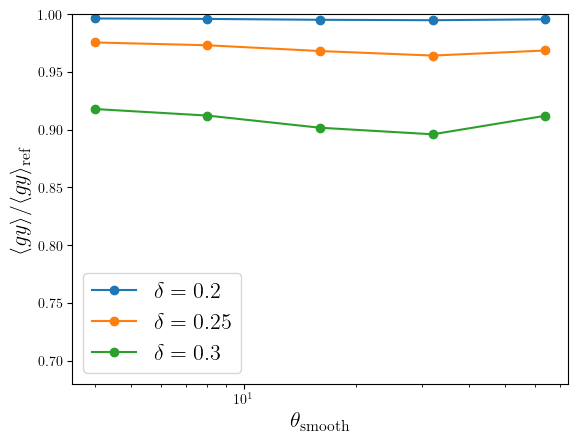

In [51]:
plt.figure()
# nu_theta_ej_M_all = [0.0, -0.15, -0.1,  -0.05,  -0.025]

for jth, nu_theta_ej_M in enumerate(delta_fshmr_all):
    gy_vals = [gy_all[(nu_theta_ej_M, theta)] for theta in theta_fwhm_all_arcmin]
    if nu_theta_ej_M == 0.0001:
        gy_ref = np.array(gy_vals)
    else:
        print(np.array(gy_vals)/gy_ref)
        plt.plot(theta_fwhm_all_arcmin, np.array(gy_vals)/gy_ref, marker='o', label=rf'$\delta= {nu_theta_ej_M}$')
plt.xlabel(r'$\theta_{\rm smooth}$', fontsize=16)
plt.ylabel(r'$\langle g y \rangle / \langle g y \rangle_{\rm ref}$', fontsize=16)
plt.legend(fontsize=16)
plt.xscale('log')
plt.ylim(0.68, 1.0)
plt.show()


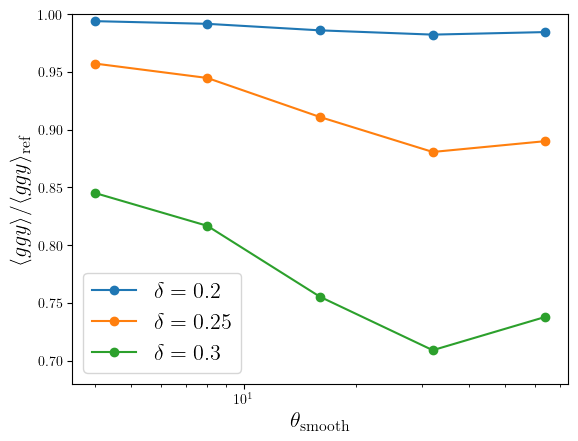

In [50]:
plt.figure()
# nu_theta_ej_M_all = [0.0, -0.15, -0.1,  -0.05,  -0.025]

for jth, nu_theta_ej_M in enumerate(delta_fshmr_all):
    g2y_vals = [g2y_all[(nu_theta_ej_M, theta)] for theta in theta_fwhm_all_arcmin]
    if nu_theta_ej_M == 0.0001:
        g2y_ref = np.array(g2y_vals)
    else:
        plt.plot(theta_fwhm_all_arcmin, np.array(g2y_vals)/g2y_ref, marker='o', label=rf'$\delta= {nu_theta_ej_M}$')
plt.xlabel(r'$\theta_{\rm smooth}$', fontsize=16)
plt.ylabel(r'$\langle g g y \rangle / \langle g g y \rangle_{\rm ref}$', fontsize=16)
plt.legend(fontsize=16)
plt.xscale('log')
plt.ylim(0.68, 1.0)
plt.show()


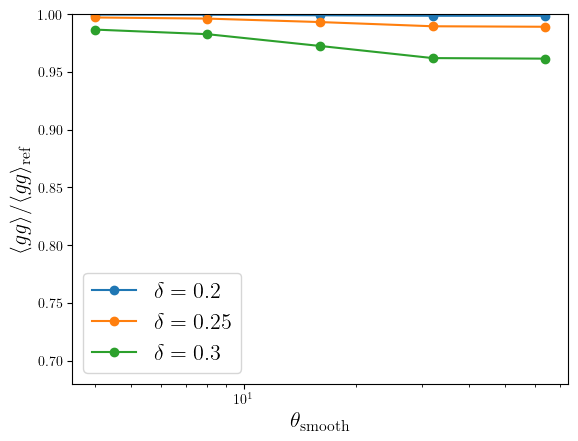

In [49]:
plt.figure()
# nu_theta_ej_M_all = [0.0, -0.15, -0.1,  -0.05,  -0.025]

for jth, nu_theta_ej_M in enumerate(delta_fshmr_all):
    gg_vals = [gg_all[(nu_theta_ej_M, theta)] for theta in theta_fwhm_all_arcmin]
    if nu_theta_ej_M == 0.0001:
        gg_ref = np.array(gg_vals)
    else:
        plt.plot(theta_fwhm_all_arcmin, np.array(gg_vals)/gg_ref, marker='o', label=rf'$\delta= {nu_theta_ej_M}$')
plt.xlabel(r'$\theta_{\rm smooth}$', fontsize=16)
plt.ylabel(r'$\langle g g \rangle / \langle g g \rangle_{\rm ref}$', fontsize=16)
plt.legend(fontsize=16)
plt.xscale('log')
plt.ylim(0.68, 1.0)
plt.show()




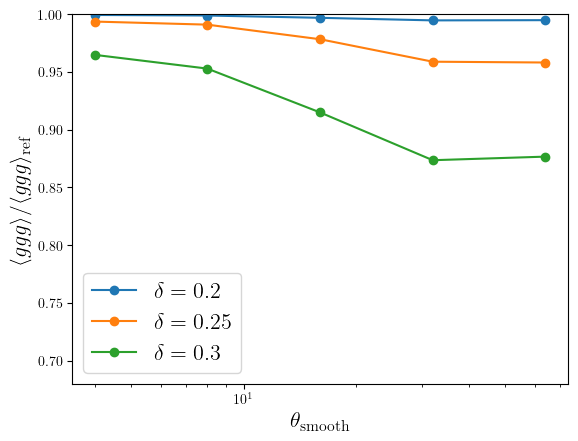

In [48]:
plt.figure()
# nu_theta_ej_M_all = [0.0, -0.15, -0.1,  -0.05,  -0.025]

for jth, nu_theta_ej_M in enumerate(delta_fshmr_all):
    g3_vals = [g3_all[(nu_theta_ej_M, theta)] for theta in theta_fwhm_all_arcmin]
    if nu_theta_ej_M == 0.0001:
        g3_ref = np.array(g3_vals)
    else:
        plt.plot(theta_fwhm_all_arcmin, np.array(g3_vals)/g3_ref, marker='o', label=rf'$\delta= {nu_theta_ej_M}$')
plt.xlabel(r'$\theta_{\rm smooth}$', fontsize=16)
plt.ylabel(r'$\langle g g g \rangle / \langle g g g \rangle_{\rm ref}$', fontsize=16)
plt.legend(fontsize=16)
plt.xscale('log')
plt.ylim(0.68, 1.0)
plt.show()


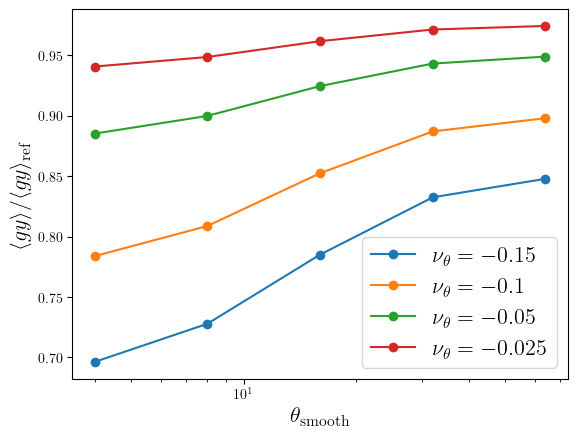

In [ ]:
# plt.figure()
# nu_theta_ej_M_all = [0.0, -0.15, -0.1,  -0.05,  -0.025]

# for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
#     gy_vals = [gy_all[(nu_theta_ej_M, theta)] for theta in theta_fwhm_all_arcmin]
#     if nu_theta_ej_M == 0:
#         gy_ref = np.array(gy_vals)
#     else:
#         plt.plot(theta_fwhm_all_arcmin, np.array(gy_vals)/gy_ref, marker='o', label=rf'$\nu_\theta= {nu_theta_ej_M}$')
# plt.xlabel(r'$\theta_{\rm smooth}$', fontsize=16)
# plt.ylabel(r'$\langle g y \rangle / \langle g y \rangle_{\rm ref}$', fontsize=16)
# plt.legend(fontsize=16)
# plt.xscale('log')
# plt.show()


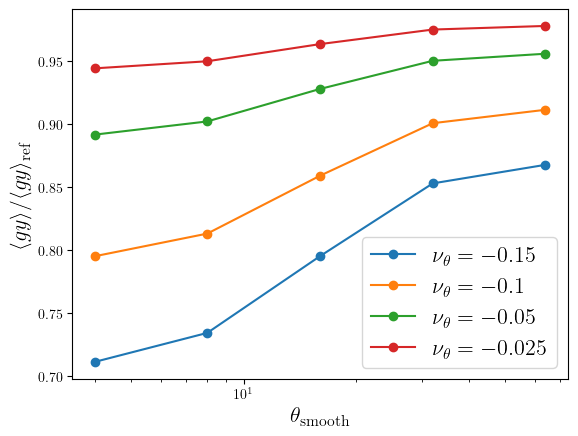

In [24]:
plt.figure()
nu_theta_ej_M_all = [0.0, -0.15, -0.1,  -0.05,  -0.025]

for jth, nu_theta_ej_M in enumerate(nu_theta_ej_M_all):
    g2y_vals = [g2y_all[(nu_theta_ej_M, theta)] for theta in theta_fwhm_all_arcmin]
    if nu_theta_ej_M == 0:
        g2y_ref = np.array(g2y_vals)
    else:
        plt.plot(theta_fwhm_all_arcmin, np.array(g2y_vals)/g2y_ref, marker='o', label=rf'$\nu_\theta= {nu_theta_ej_M}$')
plt.xlabel(r'$\theta_{\rm smooth}$', fontsize=16)
plt.ylabel(r'$\langle g y \rangle / \langle g y \rangle_{\rm ref}$', fontsize=16)
plt.legend(fontsize=16)
plt.xscale('log')
plt.show()


In [ ]:
    # cl_yy[nu_theta_ej_M] = hp.anafast(ymap_data[nu_theta_ej_M], 
    #                                ymap_data[nu_theta_ej_M], lmax=lmax)

    # cl_gy[nu_theta_ej_M] = hp.anafast(gmap_data[nu_theta_ej_M], 
    #                                ymap_data[nu_theta_ej_M], lmax=lmax)


# Reference case
cl_ref = cl_gy[0.0]

ell = np.arange(len(cl_ref))

# Plot ratios
plt.figure()
for nu_theta in nu_theta_ej_M_all[:-1]:  # Exclude reference case
    plt.plot(ell, cl_gy[nu_theta] / cl_ref, 
             label=rf'$\nu_\theta = {nu_theta}$')

plt.legend(ncol=2, fontsize=15, loc='lower left')
plt.xscale('log')
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$C_\ell^{gy} / C_\ell^{gy,\mathrm{ref}}$', fontsize=16)
plt.ylim(0.6, 1.05)
plt.tight_layout()
plt.show()


